In [ ]:
!pip install catboost -q
!pip install xgboost -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix, recall_score, precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from catboost import CatBoostClassifier
# from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

import warnings
warnings.filterwarnings('ignore')

random_state = 42

In [ ]:
df = pd.read_csv('2025_11_26_eda_final_ecg_data.csv', low_memory=False)

In [ ]:
categorical_columns = ['heart_axis_norm', 'V1_pathological_Q']
numeric_columns = ['age', 'I_prop_censored', 'II_wavelet_entropy', 'II_SNR_dB', 'III_PSD_std_freq', 'III_wavelet_E2', 'AVR_RMSSD', 'AVR_STFT_energy', 'AVR_SNR_dB', 'AVR_prop_censored', 'AVL_STFT_energy', 'AVL_SNR_dB', 'AVF_SNR_dB', 'V1_RMSSD', 'V1_STFT_energy', 'V1_wavelet_entropy', 'V1_SNR_dB', 'V2_STFT_energy', 'V2_SNR_dB', 'V2_Q_wave_amp', 'V3_STFT_energy', 'V3_SNR_dB', 'V3_Q_wave_amp', 'V4_STFT_energy', 'V4_SNR_dB', 'V5_SNR_dB', 'V5_prop_censored', 'V5_Q_wave_amp', 'V6_STFT_energy', 'V6_SNR_dB', 'V6_prop_censored', 'meanRR_global', 'V3_PSD_mean_freq', 'V5_PSD_std_freq', 'AVF_wavelet_E5', 'I_wavelet_E5', 'I_wavelet_entropy']
df['target_patology'] = 1 - df['target_norm']
target_columns = ['target_patology','target_norm', 'target_arrhythmia', 'target_infarction']

In [ ]:
df

,heart_axis_norm,V1_pathological_Q,age,I_prop_censored,II_wavelet_entropy,II_SNR_dB,III_PSD_std_freq,III_wavelet_E2,AVR_RMSSD,AVR_STFT_energy,AVR_SNR_dB,AVR_prop_censored,AVL_STFT_energy,AVL_SNR_dB,AVF_SNR_dB,V1_RMSSD,V1_STFT_energy,V1_wavelet_entropy,V1_SNR_dB,V2_STFT_energy,V2_SNR_dB,V2_Q_wave_amp,V3_STFT_energy,V3_SNR_dB,V3_Q_wave_amp,V4_STFT_energy,V4_SNR_dB,V5_SNR_dB,V5_prop_censored,V5_Q_wave_amp,V6_STFT_energy,V6_SNR_dB,V6_prop_censored,meanRR_global,V3_PSD_mean_freq,V5_PSD_std_freq,AVF_wavelet_E5,I_wavelet_E5,I_wavelet_entropy,target_norm,target_arrhythmia,target_infarction,target_patology
0,1,0,56.0,0.007,5.419053,24.614638,10.744334,0.199637,55.565277,0.000049,11.494849,0.005,0.000036,5.219391,8.615288,24.748737,0.000071,5.395219,34.069058,0.000250,29.086629,0.061861,0.000076,27.857958,0.054091,0.000050,25.957710,37.043980,0.011,0.059730,0.000063,41.418078,0.001,932.814815,12.222654,6.369762,0.076317,0.673067,5.789799,1,0,0,0
1,1,0,19.0,0.011,4.863514,11.281906,6.079428,1.519053,353.647659,0.000205,13.448662,0.004,0.000072,11.842842,10.300809,62.289646,0.000362,5.637168,13.634131,0.001357,30.604034,0.072253,0.000926,26.778794,0.097217,0.000516,36.819489,30.670310,0.012,0.102146,0.000225,22.411185,0.012,1235.629960,5.687558,9.253184,1.437292,0.888177,5.132125,1,0,0,0
2,1,0,37.0,0.013,4.893569,25.876320,6.719915,0.305148,72.543091,0.000079,23.365255,0.008,0.000059,20.288585,25.306726,26.457513,0.000074,5.683308,32.862776,0.000120,42.750413,0.067168,0.000153,20.615563,0.095022,0.000107,31.332773,18.945366,0.012,0.065056,0.000061,18.912740,0.011,940.277778,12.888998,8.601877,0.098511,1.169473,5.820171,1,0,0,0
3,1,0,24.0,0.011,5.417974,11.698055,7.043775,8.348671,36.431754,0.000411,13.678661,0.011,0.000313,10.103433,10.940353,34.785054,0.000213,5.324780,13.658337,0.000971,18.461447,0.121226,0.001628,24.705495,0.204138,0.001651,14.261899,15.788369,0.004,0.182474,0.000511,13.302702,0.003,800.542929,7.669082,7.352540,3.043082,0.954254,5.472135,1,0,0,0
4,1,0,19.0,0.004,5.682799,8.962398,7.207289,3.344558,88.443328,0.000129,10.586666,0.006,0.000047,7.062302,8.157117,56.174332,0.000110,5.674402,14.866878,0.000622,21.145494,0.087013,0.000230,17.470063,0.095123,0.000298,18.899305,20.769346,0.013,0.092893,0.000175,24.289349,0.014,901.719697,8.957262,7.656655,1.503427,0.603274,5.884295,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9788,1,0,65.0,0.020,5.565976,14.038991,9.674919,0.372015,308.883620,0.000129,21.039986,0.017,0.000069,17.152194,7.612070,13.844373,0.000539,5.315059,10.480443,0.000286,20.870502,0.076924,0.000428,22.863005,0.091999,0.000390,19.299493,6.959980,0.012,0.081504,0.001195,10.988945,0.012,675.528846,13.878109,6.132439,0.242444,3.428460,5.774914,1,0,0,0
9789,1,0,62.0,0.015,5.743448,30.886645,12.390869,0.336361,44.497191,0.000091,35.165950,0.017,0.000031,16.527702,20.731509,34.641016,0.000081,5.402677,11.602613,0.000157,12.461664,0.085806,0.000116,26.377960,0.064413,0.000241,13.832926,16.561017,0.011,0.081366,0.000266,16.377933,0.015,762.419192,12.780009,7.514803,0.827385,0.878440,5.658258,0,0,0,1
9790,1,0,57.0,0.014,5.630919,30.122040,8.087557,4.082013,50.332230,0.000150,28.960902,0.017,0.000028,30.041600,31.598596,33.166248,0.000239,5.930911,13.140118,0.000331,22.697926,0.101594,0.000219,28.921697,0.110290,0.000356,27.049591,19.490362,0.012,0.145473,0.000219,41.041483,0.014,952.000000,11.487984,7.038493,2.025029,1.309624,5.916763,1,0,0,0
9791,1,0,68.0,0.011,6.019606,36.101164,6.848050,0.387198,65.000000,0.000131,25.546448,0.001,0.000284,21.605714,21.326723,43.874822,0.000308,3.286293,5.983904,0.000215,17.969999,0.070093,0.000211,20.486240,0.071378,0.000218,22.730702,10.418927,0.006,0.098038,0.000692,4.773105,0.012,965.870370,10.392365,8.491871,0.428103,0.888371,4.337209,0,0,0,1


In [ ]:
selected_columns = ['filename_lr', 'filename_hr', 'ecg_id', 'patient_id', 'scp_codes', 'infarction_stadium1', 'infarction_stadium2']
database_selected = df[target_columns]
print(database_selected)

      target_patology  target_norm  target_arrhythmia  target_infarction
0                   0            1                  0                  0
1                   0            1                  0                  0
2                   0            1                  0                  0
3                   0            1                  0                  0
4                   0            1                  0                  0
...               ...          ...                ...                ...
9788                0            1                  0                  0
9789                1            0                  0                  0
9790                0            1                  0                  0
9791                1            0                  0                  0
9792                1            0                  0                  0

[9793 rows x 4 columns]


# **Подготовка датасетов к обучению**

In [ ]:
X = df.drop(columns=target_columns)
y = df['target_infarction']

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=random_state,
    stratify=y_temp
)
print(f"Обучающая выборка: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Валидационная выборка: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Удаляем временные переменные
del X_temp, y_temp

Обучающая выборка: 6267 (64.0%)
Валидационная выборка: 1567 (16.0%)
Тестовая выборка: 1959 (20.0%)


In [ ]:
print("Обучающая выборка:")
print(y_train.value_counts())
print(f"Дисбаланс: {y_train.value_counts()[1] / len(y_train):.3f}")

print("\nТестовая выборка:")
print(y_test.value_counts())
print(f"Дисбаланс: {y_test.value_counts()[1] / len(y_test):.3f}")

Обучающая выборка:
target_infarction
0    4926
1    1341
Name: count, dtype: int64
Дисбаланс: 0.214

Тестовая выборка:
target_infarction
0    1540
1     419
Name: count, dtype: int64
Дисбаланс: 0.214


In [ ]:
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train[numeric_columns])
X_val_numeric_scaled = scaler.transform(X_val[numeric_columns])
X_test_numeric_scaled = scaler.transform(X_test[numeric_columns])
X_train_scaled = np.hstack([X_train_numeric_scaled, X_train[categorical_columns]])
X_val_scaled = np.hstack([X_val_numeric_scaled, X_val[categorical_columns]])
X_test_scaled = np.hstack([X_test_numeric_scaled, X_test[categorical_columns]])

# **Метрика качества**

В качестве метрики качества выбра F2-мера.

Выбор F-beta-score в качестве метрики оптимизации обоснован ее способностью целенаправленно максимизировать recall при контролируемом компромиссе с precision.

Параметр beta=3 позволяет достичь recall 99.2%, что соответствует медицинскому приоритету не пропустить больных пациентов, обеспечивая при этом разумный уровень precision.

Данная метрика также обладает четкой интерпретацией для экспертов в сфере медицины - обнаружение больных в 3 раза важнее минимизации ложных тревог.

In [ ]:
f2_scorer = make_scorer(fbeta_score, beta=3, pos_label=1)

# **Функции для обработки результатов**

In [ ]:
result_df = pd.DataFrame(columns=['name', 'train_f2', 'val_f2', 'test_f2', 'val_recall', 'test_recall'])

In [ ]:
def update_results(model_name, train_f2, val_f2, test_f2, val_recall, test_recall):
    global result_df
    if model_name in result_df['name'].values:
        idx = result_df[result_df['name'] == model_name].index[0]
        result_df.loc[idx, 'train_f2'] = train_f2
        result_df.loc[idx, 'val_f2'] = val_f2
        result_df.loc[idx, 'test_f2'] = test_f2
        result_df.loc[idx, 'val_recall'] = val_recall
        result_df.loc[idx, 'test_recall'] = test_recall
    else:
        result_df.loc[len(result_df)] = [model_name, train_f2, val_f2, test_f2, val_recall, test_recall]

In [ ]:
# Функция написана с помощью Deepseek
def plot_threshold_analysis(results_df):
    """
    Функция для визуализации анализа порогов классификации

    Parameters:
    results_df: DataFrame с колонками ['threshold', 'precision', 'recall', 'f2', 'fp', 'tp', 'fn', 'tn']
    """

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(results_df['threshold'], results_df['precision'], 'bo-', label='Precision')
    plt.plot(results_df['threshold'], results_df['recall'], 'ro-', label='Recall')
    plt.xlabel('Порог')
    plt.ylabel('Score')
    plt.title('Precision и Recall для Инфаркт vs Порог')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(results_df['recall'], results_df['precision'], 'go-')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall кривая для инфаркта')
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(results_df['threshold'], results_df['fn'], 'ro-', label='False Negative')
    plt.plot(results_df['threshold'], results_df['fp'], 'bo-', label='False Positive')
    plt.xlabel('Порог')
    plt.ylabel('Количество ошибок')
    plt.title('Ошибки vs Порог')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(results_df['threshold'], results_df['f2'], 'mo-', label='F2-score')
    plt.xlabel('Порог')
    plt.ylabel('F2')
    plt.title('F2-мера vs Порог')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
class ThresholdModel:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        y_proba = self.model.predict_proba(X)[:, 1]
        return (y_proba > self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    def __getattr__(self, name):
        return getattr(self.model, name)

# **0. Обучение LogisticRegression**

В качестве baseline решения обучим модель логистической регрессии

In [ ]:
model = LogisticRegression(random_state=random_state)

param_grid = {
    'class_weight': [
        {0: 1, 1: 1},
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 1, 1: 5},
        'balanced',
        {0: 0.8, 1: 2},
        {0: 0.7, 1: 3}
    ],
    'C': [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10],
    'solver': ['liblinear', 'lbfgs', 'newton-cg'],
    'penalty': ['l2', 'l1'],
    'max_iter': [2000],
    'tol': [1e-3, 1e-4]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=10
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 1.5},
                                          {0: 1, 1: 2}, {0: 1, 1: 3},
                                          {0: 1, 1: 4}, {0: 1, 1: 5},
                                          'balanced', {0: 0.8, 1: 2},
                                          {0: 0.7, 1: 3}],
                         'max_iter': [2000], 'penalty': ['l2', 'l1'],
                         'solver': ['liblinear', 'lbfgs', 'newton-cg'],
                         'tol': [0.001, 0.0001]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=3, pos_label=1),
             verbose=10)

Лучшие гиперпараметры: {'C': 0.001, 'class_weight': {0: 1, 1: 5}, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.001}
F2 score на train 0.731927164441643
Результаты для разных порогов (1=инфаркт):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2143  1.0000 0.7318 1228 335   0    4
      0.10     0.2152  1.0000 0.7327 1222 335   0   10
      0.15     0.2178  1.0000 0.7358 1203 335   0   29
      0.20     0.2226  1.0000 0.7412 1170 335   0   62
      0.25     0.2311  0.9970 0.7489 1111 334   1  121
      0.30     0.2416  0.9881 0.7548 1039 331   4  193
      0.35     0.2616  0.9731 0.7651  920 326   9  312
      0.40     0.2826  0.9433 0.7646  802 316  19  430
      0.45     0.3148  0.9104 0.7656  664 305  30  568
      0.50     0.3511  0.8448 0.7406  523 283  52  709
      0.55     0.3761  0.7343 0.6705  408 246  89  824
      0.60     0.4019  0.6179 0.5864  308 207 128  924
      0.65     0.4378  0.4836 0.4786  208 162 173 1024
      0.70     0.

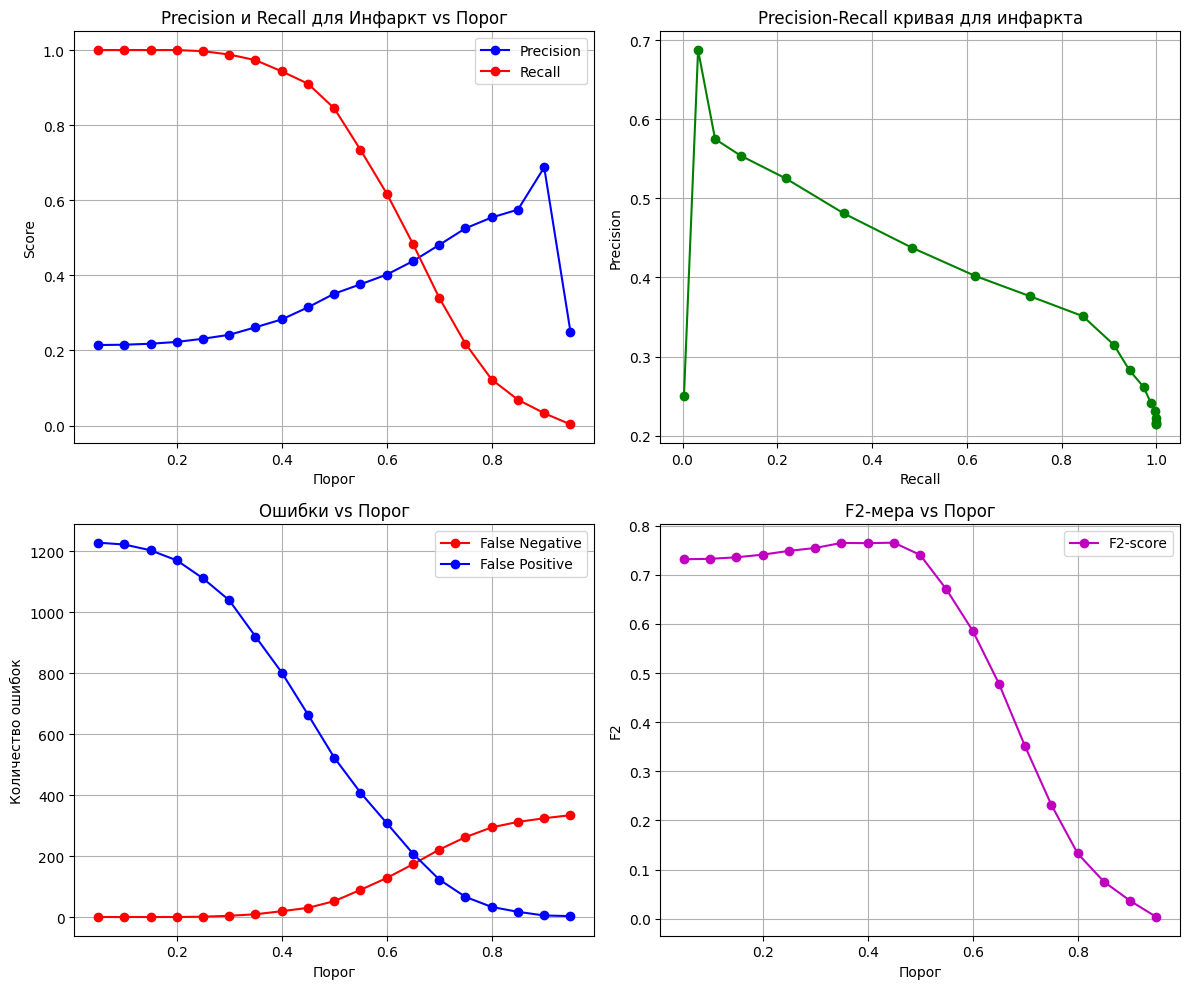

In [ ]:
print('Лучшие гиперпараметры:', grid_search.best_params_)
print('F2 score на train', grid_search.best_score_)
best_model = grid_search.best_estimator_
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
thresholds = np.arange(0.05, 1.0, 0.05)
results = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_val, y_val_pred, pos_label=1)
    f2 = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

    results.append({
        'threshold': round(threshold, 2),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f2': round(f2, 4),
        'fp': fp,
        'tp': tp,
        'fn': fn,
        'tn': tn
    })

threshold_select_results = pd.DataFrame(results)
print("Результаты для разных порогов (1=инфаркт):")
print(threshold_select_results.to_string(index=False))
plot_threshold_analysis(threshold_select_results)

Пороговая вероятность = 0.25.

Здесь и далее будет выбрана пороговая вероятность, обеспечивающая значения recall равным около 99 процентов. Сравнений моделей будет выполнено с помощью метрики f2-мера, при recall около 99 процентов.

In [ ]:
selected_threshold = 0.25

best_model = grid_search.best_estimator_
best_model_with_threshold = ThresholdModel(best_model, threshold=selected_threshold)

y_val_pred = best_model_with_threshold.predict(X_val_scaled)
y_test_pred = best_model_with_threshold.predict(X_test_scaled)
f2_val = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)
recall_val = recall_score(y_val, y_val_pred, pos_label=1)

f2_test = fbeta_score(y_test, y_test_pred, beta=3, pos_label=1, zero_division=0)
recall_test = recall_score(y_test, y_test_pred, pos_label=1)
update_results(f'LogisticRegression. Prob_threshold={selected_threshold}', grid_search.best_score_, f2_val, f2_test, recall_val, recall_test)

In [ ]:
result_df

,name,train_f2,val_f2,test_f2,val_recall,test_recall
0,LogisticRegression. Prob_threshold=0.25,0.731927,0.748879,0.75292,0.997015,1.0


# **1. Обучение DecisionTree**

Модель выбрана в качестве базовой модели для оценки простых нелинейных закономерностей

In [ ]:
model = DecisionTreeClassifier(random_state=random_state)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 20, 50, 100, 200, 500],
    'min_samples_leaf': [1, 2, 5, 10, 20, 30, 50, 100],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5, 0.7],
    'ccp_alpha': [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.1],
    'class_weight': [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5},
                     {0: 1, 1: 7}, {0: 1, 1: 10}, 'balanced'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=10
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 145152 candidates, totalling 725760 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05,
                                       0.1],
                         'class_weight': [{0: 1, 1: 2}, {0: 1, 1: 3},
                                          {0: 1, 1: 5}, {0: 1, 1: 7},
                                          {0: 1, 1: 10}, 'balanced'],
                         'max_depth': [3, 5, 7, 10, 15, 20, 25, 30, None],
                         'max_features': ['sqrt', 'log2', None, 0.3, 0.5, 0.7],
                         'min_samples_leaf': [1, 2, 5, 10, 20, 30, 50, 100],
                         'min_samples_split': [2, 5, 10, 20, 50, 100, 200,
                                               500]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=3, pos_label=1),
             verbose=10)

Лучшие гиперпараметры: {'ccp_alpha': 0.005, 'class_weight': {0: 1, 1: 10}, 'max_depth': 10, 'max_features': 0.7, 'min_samples_leaf': 50, 'min_samples_split': 200}
F2 score на train 0.7630972955256528
Результаты для разных порогов (1=инфаркт):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2138  1.0000 0.7311 1232 335   0    0
      0.10     0.2215  0.9970 0.7384 1174 334   1   58
      0.15     0.2215  0.9970 0.7384 1174 334   1   58
      0.20     0.2215  0.9970 0.7384 1174 334   1   58
      0.25     0.2215  0.9970 0.7384 1174 334   1   58
      0.30     0.2215  0.9970 0.7384 1174 334   1   58
      0.35     0.2844  0.9254 0.7552  780 310  25  452
      0.40     0.2844  0.9254 0.7552  780 310  25  452
      0.45     0.2844  0.9254 0.7552  780 310  25  452
      0.50     0.2844  0.9254 0.7552  780 310  25  452
      0.55     0.2844  0.9254 0.7552  780 310  25  452
      0.60     0.2844  0.9254 0.7552  780 310  25  452
      0.65     0.2844  0.9254 0.7552  780 

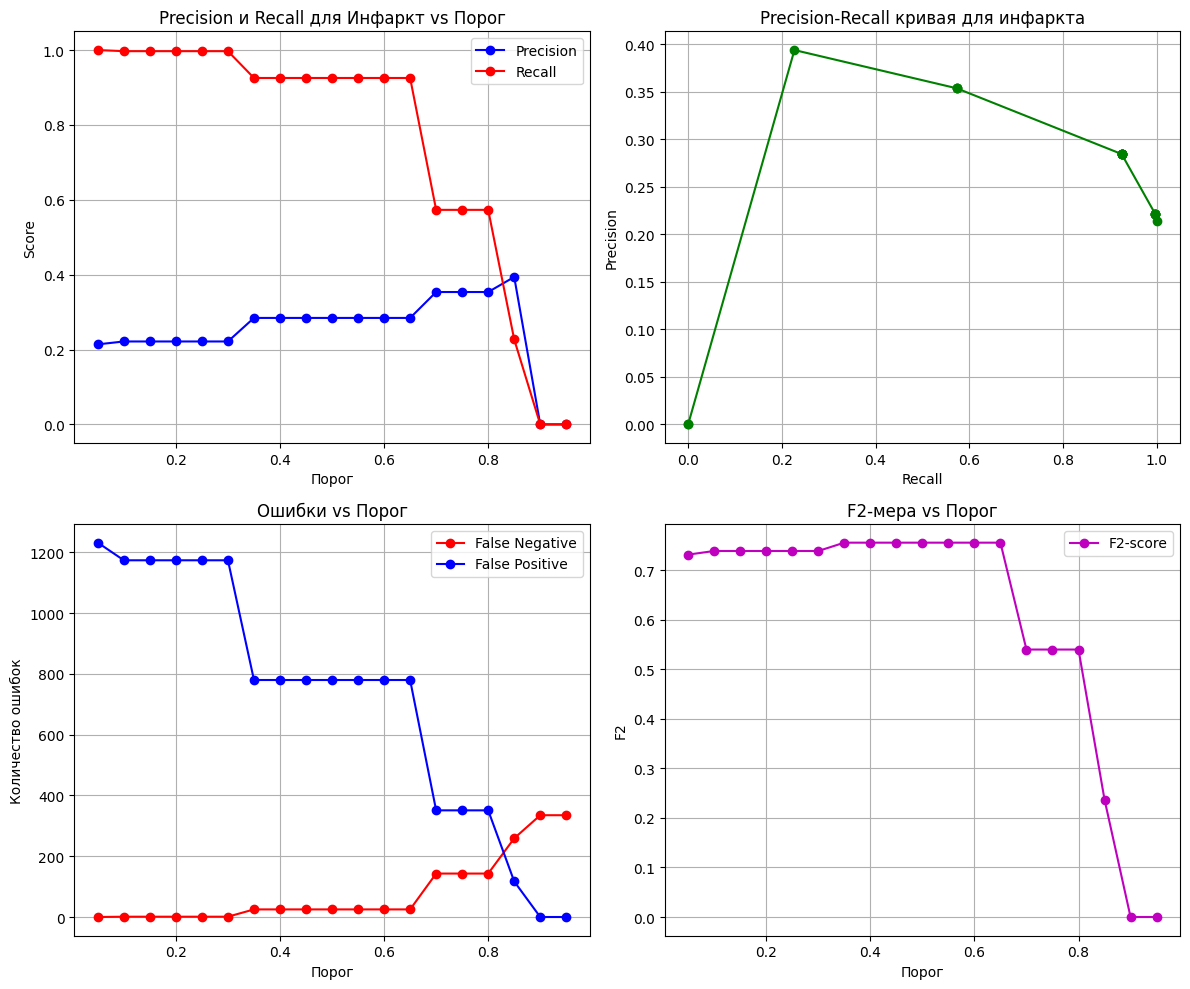

In [ ]:
print('Лучшие гиперпараметры:', grid_search.best_params_)
print('F2 score на train', grid_search.best_score_)
best_model = grid_search.best_estimator_
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
thresholds = np.arange(0.05, 1.0, 0.05)
results = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_val, y_val_pred, pos_label=1)
    f2 = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

    results.append({
        'threshold': round(threshold, 2),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f2': round(f2, 4),
        'fp': fp,
        'tp': tp,
        'fn': fn,
        'tn': tn
    })

threshold_select_results = pd.DataFrame(results)
print("Результаты для разных порогов (1=инфаркт):")
print(threshold_select_results.to_string(index=False))
plot_threshold_analysis(threshold_select_results)

In [ ]:
selected_threshold = 0.3

best_model = grid_search.best_estimator_
best_model_with_threshold = ThresholdModel(best_model, threshold=selected_threshold)

y_val_pred = best_model_with_threshold.predict(X_val_scaled)
y_test_pred = best_model_with_threshold.predict(X_test_scaled)
f2_val = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)
recall_val = recall_score(y_val, y_val_pred, pos_label=1)

f2_test = fbeta_score(y_test, y_test_pred, beta=3, pos_label=1, zero_division=0)
recall_test = recall_score(y_test, y_test_pred, pos_label=1)
update_results(f'DecisionTree. Prob_threshold={selected_threshold}', grid_search.best_score_, f2_val, f2_test, recall_val, recall_test)

In [ ]:
result_df

,name,train_f2,val_f2,test_f2,val_recall,test_recall
0,LogisticRegression. Prob_threshold=0.25,0.731927,0.748879,0.752920,0.997015,1.0
1,DecisionTree. Prob_threshold=0.3,0.763097,0.738448,0.736898,0.997015,1.0


Логистическая регрессия показала более стабильным результаты на валидации и тесте.

In [ ]:
import pickle
import joblib

model_name = 'DecisionTree'

model_package_infarction = {
    'model_with_threshold': best_model_with_threshold,
    'raw_model': best_model,
    'feature_order': list(X.columns),
    'numeric_columns': numeric_columns,
    'categorical_columns': categorical_columns,
    'best_params': grid_search.best_params_,
    'best_score': grid_search.best_score_,
    'selected_threshold': selected_threshold,
    'threshold_analysis': threshold_select_results
}

joblib.dump(model_package_infarction, f'{model_name}.joblib')

with open(f'{model_name}.pkl', 'wb') as f:
    pickle.dump(model_package_infarction, f)

print(model_package_infarction)

{'model_with_threshold': <__main__.ThresholdModel object at 0x000001D0EA30EFD0>, 'raw_model': DecisionTreeClassifier(ccp_alpha=0.005, class_weight={0: 1, 1: 10},
                       max_depth=10, max_features=0.7, min_samples_leaf=50,
                       min_samples_split=200, random_state=42), 'feature_order': ['heart_axis_norm', 'V1_pathological_Q', 'age', 'I_prop_censored', 'II_wavelet_entropy', 'II_SNR_dB', 'III_PSD_std_freq', 'III_wavelet_E2', 'AVR_RMSSD', 'AVR_STFT_energy', 'AVR_SNR_dB', 'AVR_prop_censored', 'AVL_STFT_energy', 'AVL_SNR_dB', 'AVF_SNR_dB', 'V1_RMSSD', 'V1_STFT_energy', 'V1_wavelet_entropy', 'V1_SNR_dB', 'V2_STFT_energy', 'V2_SNR_dB', 'V2_Q_wave_amp', 'V3_STFT_energy', 'V3_SNR_dB', 'V3_Q_wave_amp', 'V4_STFT_energy', 'V4_SNR_dB', 'V5_SNR_dB', 'V5_prop_censored', 'V5_Q_wave_amp', 'V6_STFT_energy', 'V6_SNR_dB', 'V6_prop_censored', 'meanRR_global', 'V3_PSD_mean_freq', 'V5_PSD_std_freq', 'AVF_wavelet_E5', 'I_wavelet_E5', 'I_wavelet_entropy'], 'numeric_columns': ['a

# **2. Обучение RandomForest**

Оценка ансамбля решиющих деревьев для снижения переобучения.

In [ ]:
model = RandomForestClassifier(random_state=random_state)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [50, 100, 200],
    'min_samples_leaf': [20, 30, 50],
    'max_features': [0.7],
    'class_weight': [{0: 1, 1: 10}, {0: 1, 1: 15}],
    'bootstrap': [True],
    'ccp_alpha': [0.005],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=4,
    verbose=10
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42), n_jobs=4,
             param_grid={'bootstrap': [True], 'ccp_alpha': [0.005],
                         'class_weight': [{0: 1, 1: 10}, {0: 1, 1: 15}],
                         'max_depth': [10, 15, 20, 25], 'max_features': [0.7],
                         'min_samples_leaf': [20, 30, 50],
                         'min_samples_split': [50, 100, 200],
                         'n_estimators': [200, 300]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=3, pos_label=1),
             verbose=10)

Лучшие гиперпараметры: {'bootstrap': True, 'ccp_alpha': 0.005, 'class_weight': {0: 1, 1: 10}, 'max_depth': 10, 'max_features': 0.7, 'min_samples_leaf': 20, 'min_samples_split': 50, 'n_estimators': 200}
F2 score на train 0.776297397477073
Результаты для разных порогов (1=инфаркт):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2138  1.0000 0.7311 1232 335   0    0
      0.10     0.2138  1.0000 0.7311 1232 335   0    0
      0.15     0.2138  1.0000 0.7311 1232 335   0    0
      0.20     0.2296  0.9970 0.7472 1121 334   1  111
      0.25     0.2353  0.9940 0.7517 1082 333   2  150
      0.30     0.2425  0.9881 0.7557 1034 331   4  198
      0.35     0.2498  0.9821 0.7595  988 329   6  244
      0.40     0.2573  0.9731 0.7613  941 326   9  291
      0.45     0.2669  0.9642 0.7645  887 323  12  345
      0.50     0.2811  0.9433 0.7635  808 316  19  424
      0.55     0.2986  0.9164 0.7593  721 307  28  511
      0.60     0.3180  0.8896 0.7540  639 298  37  593
    

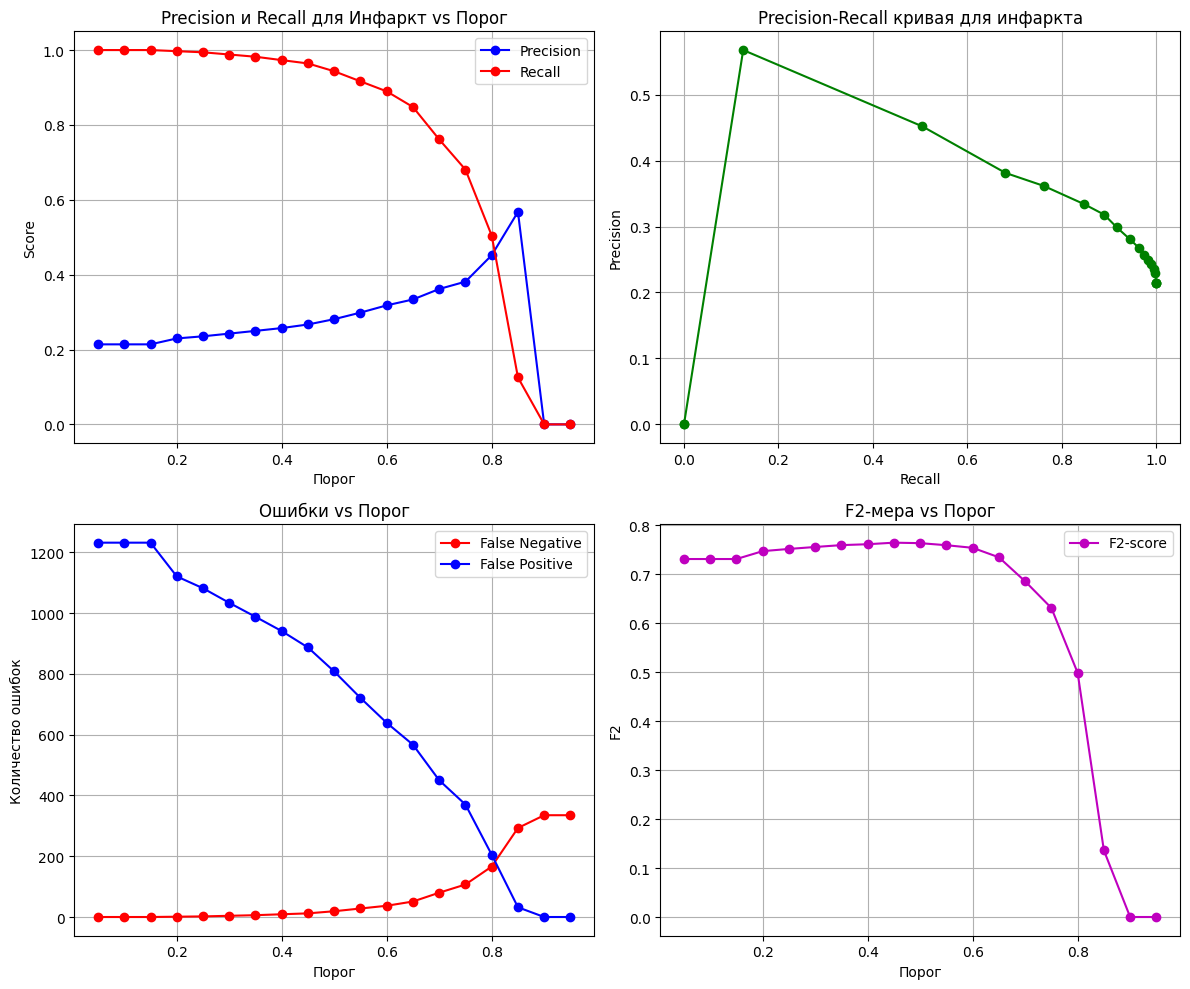

In [ ]:
print('Лучшие гиперпараметры:', grid_search.best_params_)
print('F2 score на train', grid_search.best_score_)
best_model = grid_search.best_estimator_
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
thresholds = np.arange(0.05, 1.0, 0.05)
results = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_val, y_val_pred, pos_label=1)
    f2 = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

    results.append({
        'threshold': round(threshold, 2),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f2': round(f2, 4),
        'fp': fp,
        'tp': tp,
        'fn': fn,
        'tn': tn
    })

threshold_select_results = pd.DataFrame(results)
print("Результаты для разных порогов (1=инфаркт):")
print(threshold_select_results.to_string(index=False))
plot_threshold_analysis(threshold_select_results)

In [ ]:
selected_threshold = 0.2

best_model = grid_search.best_estimator_
best_model_with_threshold = ThresholdModel(best_model, threshold=selected_threshold)

y_val_pred = best_model_with_threshold.predict(X_val_scaled)
y_test_pred = best_model_with_threshold.predict(X_test_scaled)
f2_val = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)
recall_val = recall_score(y_val, y_val_pred, pos_label=1)

f2_test = fbeta_score(y_test, y_test_pred, beta=3, pos_label=1, zero_division=0)
recall_test = recall_score(y_test, y_test_pred, pos_label=1)
update_results(f'RandomForest. Prob_threshold={selected_threshold}', grid_search.best_score_, f2_val, f2_test, recall_val, recall_test)

In [ ]:
result_df

,name,train_f2,val_f2,test_f2,val_recall,test_recall
0,LogisticRegression. Prob_threshold=0.25,0.731927,0.748879,0.752920,0.997015,1.000000
1,DecisionTree. Prob_threshold=0.3,0.763097,0.738448,0.736898,0.997015,1.000000
2,RandomForest. Prob_threshold=0.2,0.776297,0.747204,0.747096,0.997015,0.997613


Логистическая регрессия и случайный лес показали схожее значение метрики на val и test.

In [ ]:
import pickle
import joblib

model_name = 'RandomForest'

model_package_infarction = {
    'model_with_threshold': best_model_with_threshold,
    'raw_model': best_model,
    'feature_order': list(X.columns),
    'numeric_columns': numeric_columns,
    'categorical_columns': categorical_columns,
    'best_params': grid_search.best_params_,
    'best_score': grid_search.best_score_,
    'selected_threshold': selected_threshold,
    'threshold_analysis': threshold_select_results
}

joblib.dump(model_package_infarction, f'{model_name}.joblib')

with open(f'{model_name}.pkl', 'wb') as f:
    pickle.dump(model_package_infarction, f)

print(model_package_infarction)

{'model_with_threshold': <__main__.ThresholdModel object at 0x000001D0E7EF72F0>, 'raw_model': RandomForestClassifier(ccp_alpha=0.005, class_weight={0: 1, 1: 10},
                       max_depth=10, max_features=0.7, min_samples_leaf=20,
                       min_samples_split=50, n_estimators=200, random_state=42), 'feature_order': ['heart_axis_norm', 'V1_pathological_Q', 'age', 'I_prop_censored', 'II_wavelet_entropy', 'II_SNR_dB', 'III_PSD_std_freq', 'III_wavelet_E2', 'AVR_RMSSD', 'AVR_STFT_energy', 'AVR_SNR_dB', 'AVR_prop_censored', 'AVL_STFT_energy', 'AVL_SNR_dB', 'AVF_SNR_dB', 'V1_RMSSD', 'V1_STFT_energy', 'V1_wavelet_entropy', 'V1_SNR_dB', 'V2_STFT_energy', 'V2_SNR_dB', 'V2_Q_wave_amp', 'V3_STFT_energy', 'V3_SNR_dB', 'V3_Q_wave_amp', 'V4_STFT_energy', 'V4_SNR_dB', 'V5_SNR_dB', 'V5_prop_censored', 'V5_Q_wave_amp', 'V6_STFT_energy', 'V6_SNR_dB', 'V6_prop_censored', 'meanRR_global', 'V3_PSD_mean_freq', 'V5_PSD_std_freq', 'AVF_wavelet_E5', 'I_wavelet_E5', 'I_wavelet_entropy'], 'nume

# **3. Обучение XGBoost**

Выбран в качестве одного из эффективных алгоритмов градиентного бустинга

In [ ]:
model = XGBClassifier(random_state=random_state)

param_grid = {
    'n_estimators': [200],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'reg_lambda': [1, 3, 5],
    'reg_alpha': [0, 1],
    'min_child_weight': [3, 5],
    'colsample_bytree': [0.7, 0.8],
    'scale_pos_weight': [10, 15],
    'subsample': [0.7],
    'gamma': [0],
    'tree_method': ['hist']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=4,
    verbose=10
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_polic...
             n_jobs=4,
             param_grid={'colsample_bytree': [0.7, 0.8], 'gamma': [0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [6, 8, 10],
                         'min_child_weight': [3, 5], 'n_estimators': [200],
                         'reg_alpha': [0, 1], 'reg_lambda': [1, 3, 5],
                         'scale_pos_weight': [10, 15], 'subsample': [0.7],
                         'tree_method': ['hist']},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=3, pos_label=1),
             verbose=10)

Лучшие гиперпараметры: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 5, 'scale_pos_weight': 15, 'subsample': 0.7, 'tree_method': 'hist'}
F2 score на train 0.7573756012377104
Результаты для разных порогов (1=инфаркт):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2459  0.9940 0.7622 1021 333   2  211
      0.10     0.2721  0.9731 0.7738  872 326   9  360
      0.15     0.2972  0.9582 0.7839  759 321  14  473
      0.20     0.3144  0.9433 0.7861  689 316  19  543
      0.25     0.3312  0.9224 0.7827  624 309  26  608
      0.30     0.3497  0.9134 0.7866  569 306  29  663
      0.35     0.3611  0.8925 0.7780  529 299  36  703
      0.40     0.3758  0.8716 0.7700  485 292  43  747
      0.45     0.3912  0.8478 0.7592  442 284  51  790
      0.50     0.4077  0.8179 0.7432  398 274  61  834
      0.55     0.4302  0.7821 0.7230  347 262  73  885
      0.60     0.4

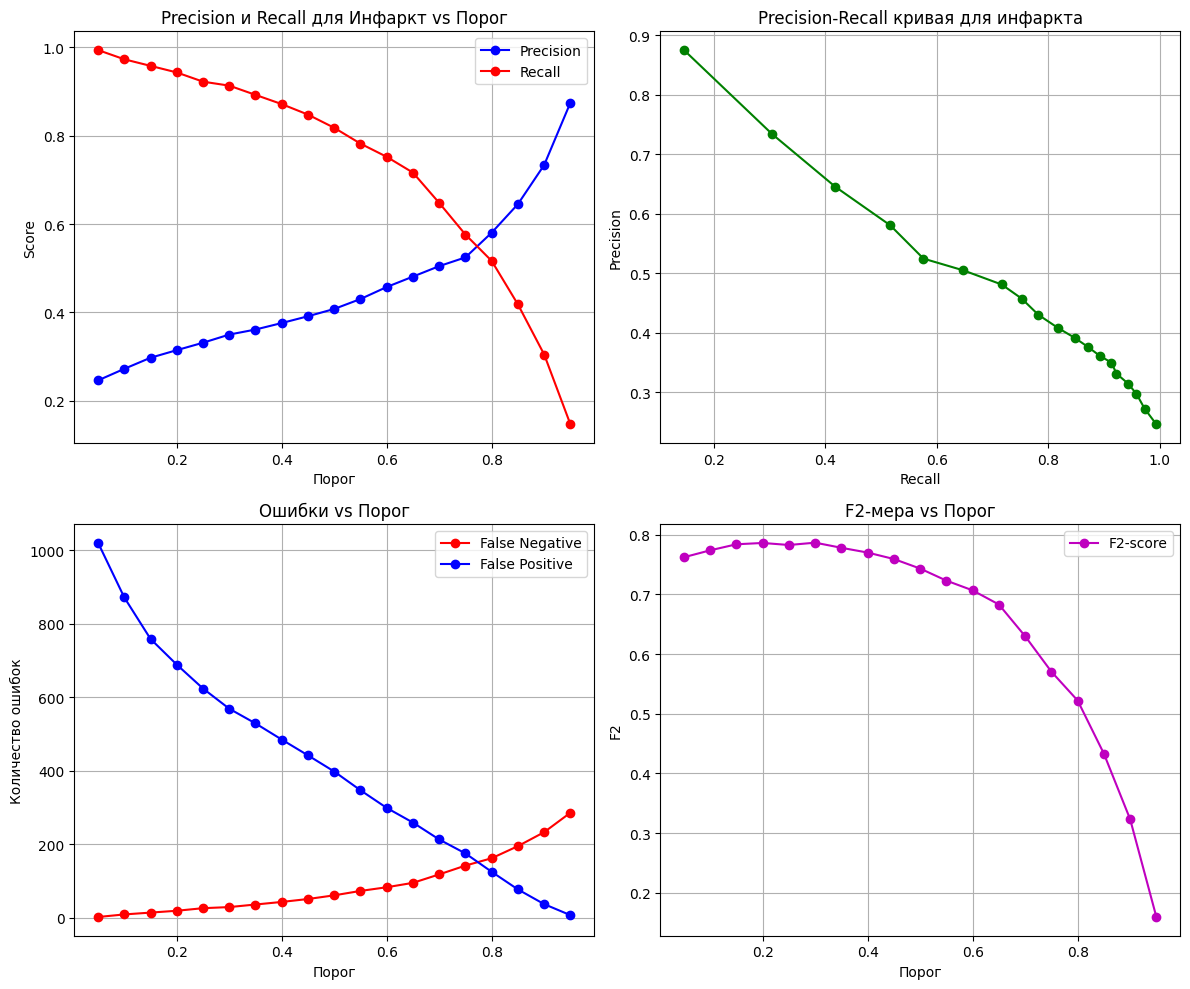

In [ ]:
print('Лучшие гиперпараметры:', grid_search.best_params_)
print('F2 score на train', grid_search.best_score_)
best_model = grid_search.best_estimator_
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
thresholds = np.arange(0.05, 1.0, 0.05)
results = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_val, y_val_pred, pos_label=1)
    f2 = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

    results.append({
        'threshold': round(threshold, 2),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f2': round(f2, 4),
        'fp': fp,
        'tp': tp,
        'fn': fn,
        'tn': tn
    })

threshold_select_results = pd.DataFrame(results)
print("Результаты для разных порогов (1=инфаркт):")
print(threshold_select_results.to_string(index=False))
plot_threshold_analysis(threshold_select_results)

In [ ]:
selected_threshold = 0.05

best_model = grid_search.best_estimator_
best_model_with_threshold = ThresholdModel(best_model, threshold=selected_threshold)

y_val_pred = best_model_with_threshold.predict(X_val_scaled)
y_test_pred = best_model_with_threshold.predict(X_test_scaled)
f2_val = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)
recall_val = recall_score(y_val, y_val_pred, pos_label=1)

f2_test = fbeta_score(y_test, y_test_pred, beta=3, pos_label=1, zero_division=0)
recall_test = recall_score(y_test, y_test_pred, pos_label=1)
update_results(f'XGBoost. Prob_threshold={selected_threshold}', grid_search.best_score_, f2_val, f2_test, recall_val, recall_test)

In [ ]:
result_df

,name,train_f2,val_f2,test_f2,val_recall,test_recall
0,LogisticRegression. Prob_threshold=0.25,0.731927,0.748879,0.752920,0.997015,1.000000
1,DecisionTree. Prob_threshold=0.3,0.763097,0.738448,0.736898,0.997015,1.000000
2,RandomForest. Prob_threshold=0.2,0.776297,0.747204,0.747096,0.997015,0.997613
3,XGBoost. Prob_threshold=0.05,0.757376,0.762188,0.766255,0.994030,0.992840


XGBoost показывает наилучшие результаты на val и test при высоком recall.

In [ ]:
import pickle
import joblib

model_name = 'XGBoost'

# 3. Сохраняем полный пакет
model_package_infarction = {
    'model_with_threshold': best_model_with_threshold,
    'raw_model': best_model,
    'feature_order': list(X.columns),
    'numeric_columns': numeric_columns,
    'categorical_columns': categorical_columns,
    'best_params': grid_search.best_params_,
    'best_score': grid_search.best_score_,
    'selected_threshold': selected_threshold,
    'threshold_analysis': threshold_select_results
}

joblib.dump(model_package_infarction, f'{model_name}.joblib')

with open(f'{model_name}.pkl', 'wb') as f:
    pickle.dump(model_package_infarction, f)

print(model_package_infarction)

{'model_with_threshold': <__main__.ThresholdModel object at 0x000001D0E7EA7DF0>, 'raw_model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...), 'feature_order': ['heart_axis_norm', 'V1_pathological_Q', 'age', 'I_prop_censored', 'II_wavelet_entropy', 'II_SNR_dB', 'III_PSD_std_freq', 'III_wavelet_E2'

# **4. Обучение CatBoost**

Выбран в качестве эффективной алгоритма градиентного бустинга.

In [ ]:
model = CatBoostClassifier(random_state=random_state, verbose=100)

# param_grid = {
#     'iterations': [200],
#     'depth': [5, 6, 7],
#     'learning_rate': [0.05, 0.1],
#     'l2_leaf_reg': [1, 3, 5],
#     'colsample_bylevel': [0.7, 0.8],
#     'class_weights': [[1, 10], [1, 15]],
#     'bootstrap_type': ['Bernoulli'],
#     'boosting_type': ['Plain'],
#     'min_data_in_leaf': [5, 10],
#     'subsample': [0.7]
# }

param_grid = {
    'iterations': [200],
    'depth': [6, 8, 10],
    'learning_rate': [0.05],
    'l2_leaf_reg': [1, 3, 5],
    'colsample_bylevel': [0.5, 0.7, 1.0],
    'class_weights': [[1, 10], [1, 20]],
    'bootstrap_type': ['Bernoulli'],
    'boosting_type': ['Plain'],
    'min_data_in_leaf': [5, 10, 25, 50],
    'subsample': [0.7, 1.0],
    'grow_policy': ['SymmetricTree', 'Depthwise', 'Lossguide'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=4,
    verbose=10
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
0:	learn: 0.6595757	total: 22.2ms	remaining: 4.43s
100:	learn: 0.2839577	total: 769ms	remaining: 754ms
199:	learn: 0.2347566	total: 1.57s	remaining: 0us


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=CatBoostClassifier(random_state=42, verbose=100),
             n_jobs=4,
             param_grid={'boosting_type': ['Plain'],
                         'bootstrap_type': ['Bernoulli'],
                         'class_weights': [[1, 10], [1, 20]],
                         'colsample_bylevel': [0.5, 0.7, 1.0],
                         'depth': [6, 8, 10],
                         'grow_policy': ['SymmetricTree', 'Depthwise',
                                         'Lossguide'],
                         'iterations': [200], 'l2_leaf_reg': [1, 3, 5],
                         'learning_rate': [0.05],
                         'min_data_in_leaf': [5, 10, 25, 50],
                         'subsample': [0.7, 1.0]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=3, pos_label=1),
             verbose=10)

Лучшие гиперпараметры: {'boosting_type': 'Plain', 'bootstrap_type': 'Bernoulli', 'class_weights': [1, 20], 'colsample_bylevel': 1.0, 'depth': 6, 'grow_policy': 'Lossguide', 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.05, 'min_data_in_leaf': 10, 'subsample': 0.7}
F2 score на train 0.7985065361083573
Результаты для разных порогов (1=инфаркт):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2251  1.0000 0.7439 1153 335   0   79
      0.10     0.2325  0.9940 0.7488 1099 333   2  133
      0.15     0.2437  0.9821 0.7537 1021 329   6  211
      0.20     0.2519  0.9791 0.7598  974 328   7  258
      0.25     0.2622  0.9761 0.7672  920 327   8  312
      0.30     0.2729  0.9701 0.7727  866 325  10  366
      0.35     0.2835  0.9672 0.7792  819 324  11  413
      0.40     0.2951  0.9612 0.7842  769 322  13  463
      0.45     0.3095  0.9582 0.7922  716 321  14  516
      0.50     0.3228  0.9433 0.7912  663 316  19  569
      0.55     0.3380  0.9284 0.7903  60

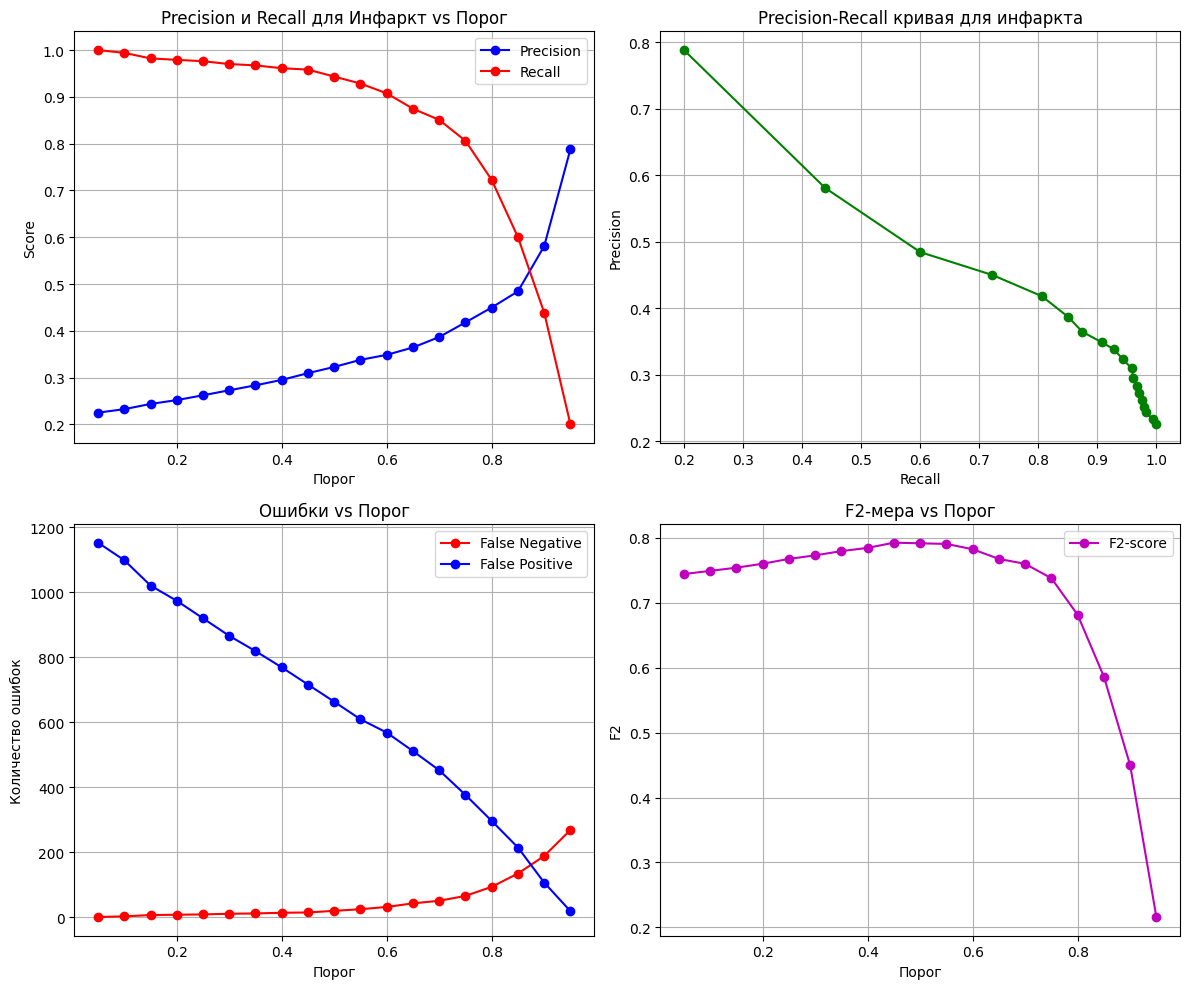

In [ ]:
print('Лучшие гиперпараметры:', grid_search.best_params_)
print('F2 score на train', grid_search.best_score_)
best_model = grid_search.best_estimator_
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
thresholds = np.arange(0.05, 1.0, 0.05)
results = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_val, y_val_pred, pos_label=1)
    f2 = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

    results.append({
        'threshold': round(threshold, 2),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f2': round(f2, 4),
        'fp': fp,
        'tp': tp,
        'fn': fn,
        'tn': tn
    })

threshold_select_results = pd.DataFrame(results)
print("Результаты для разных порогов (1=инфаркт):")
print(threshold_select_results.to_string(index=False))
plot_threshold_analysis(threshold_select_results)

In [ ]:
selected_threshold = 0.15

best_model = grid_search.best_estimator_
best_model_with_threshold = ThresholdModel(best_model, threshold=selected_threshold)

y_val_pred = best_model_with_threshold.predict(X_val_scaled)
y_test_pred = best_model_with_threshold.predict(X_test_scaled)
f2_val = fbeta_score(y_val, y_val_pred, beta=3, pos_label=1, zero_division=0)
recall_val = recall_score(y_val, y_val_pred, pos_label=1)

f2_test = fbeta_score(y_test, y_test_pred, beta=3, pos_label=1, zero_division=0)
recall_test = recall_score(y_test, y_test_pred, pos_label=1)
update_results(f'CatBoost. Prob_threshold={selected_threshold}', grid_search.best_score_, f2_val, f2_test, recall_val, recall_test)

In [ ]:
result_df

,name,train_f2,val_f2,test_f2,val_recall,test_recall
0,LogisticRegression. Prob_threshold=0.25,0.731927,0.748879,0.752920,0.997015,1.000000
1,DecisionTree. Prob_threshold=0.3,0.763097,0.738448,0.736898,0.997015,1.000000
2,RandomForest. Prob_threshold=0.2,0.776297,0.747204,0.747096,0.997015,0.997613
3,XGBoost. Prob_threshold=0.05,0.757376,0.762188,0.766255,0.994030,0.992840
4,CatBoost. Prob_threshold=0.15,0.798507,0.753723,0.761887,0.982090,0.990453


CatBoost показывает немного меньше значения метрик на val и test относительно XGBoost.

In [ ]:
import pickle
import joblib

model_name = 'CatBoost'

model_package_infarction = {
    'model_with_threshold': best_model_with_threshold,
    'raw_model': best_model,
    'feature_order': list(X.columns),
    'numeric_columns': numeric_columns,
    'categorical_columns': categorical_columns,
    'best_params': grid_search.best_params_,
    'best_score': grid_search.best_score_,
    'selected_threshold': selected_threshold,
    'threshold_analysis': threshold_select_results
}

joblib.dump(model_package_infarction, f'{model_name}.joblib')

with open(f'{model_name}.pkl', 'wb') as f:
    pickle.dump(model_package_infarction, f)

print(model_package_infarction)

{'model_with_threshold': <__main__.ThresholdModel object at 0x000001D0A9350490>, 'raw_model': CatBoostClassifier(boosting_type='Plain', bootstrap_type='Bernoulli', class_weights=[1, 15], colsample_bylevel=0.7, depth=7, iterations=200, l2_leaf_reg=5, learning_rate=0.05, min_data_in_leaf=5, random_state=42, subsample=0.7, verbose=100), 'feature_order': ['heart_axis_norm', 'V1_pathological_Q', 'age', 'I_prop_censored', 'II_wavelet_entropy', 'II_SNR_dB', 'III_PSD_std_freq', 'III_wavelet_E2', 'AVR_RMSSD', 'AVR_STFT_energy', 'AVR_SNR_dB', 'AVR_prop_censored', 'AVL_STFT_energy', 'AVL_SNR_dB', 'AVF_SNR_dB', 'V1_RMSSD', 'V1_STFT_energy', 'V1_wavelet_entropy', 'V1_SNR_dB', 'V2_STFT_energy', 'V2_SNR_dB', 'V2_Q_wave_amp', 'V3_STFT_energy', 'V3_SNR_dB', 'V3_Q_wave_amp', 'V4_STFT_energy', 'V4_SNR_dB', 'V5_SNR_dB', 'V5_prop_censored', 'V5_Q_wave_amp', 'V6_STFT_energy', 'V6_SNR_dB', 'V6_prop_censored', 'meanRR_global', 'V3_PSD_mean_freq', 'V5_PSD_std_freq', 'AVF_wavelet_E5', 'I_wavelet_E5', 'I_wavelet

# **Важность признаков**

In [ ]:
model = XGBClassifier(random_state=random_state)

param_grid = {
    'n_estimators': [200],
    'max_depth': [6],
    'learning_rate': [0.05],
    'reg_lambda': [ 5],
    'reg_alpha': [1],
    'min_child_weight': [5],
    'colsample_bytree': [0.8],
    'scale_pos_weight': [15],
    'subsample': [0.7],
    'gamma': [0],
    'tree_method': ['hist']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=4,
    verbose=10
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_polic...
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=4,
             param_grid={'colsample_bytree': [0.8], 'gamma': [0],
                         'learning_rate': [0.05], 'max_depth': [6],
                         'min_child_weight': [5], 'n_estimators': [200],
                         'reg_alpha': [1], 'reg_lambda': [5],
                         'scale_pos_weight': [15], 'subsample': [0.7],
                         'tree_method': ['hist']},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=3, pos_label=1, zero_division=0),
             verbose=10)

               feature  importance
0      heart_axis_norm    0.081341
37        I_wavelet_E5    0.076931
5            II_SNR_dB    0.044875
7       III_wavelet_E2    0.044781
15            V1_RMSSD    0.040787
10          AVR_SNR_dB    0.035845
38   I_wavelet_entropy    0.030705
32    V6_prop_censored    0.029834
11   AVR_prop_censored    0.027005
13          AVL_SNR_dB    0.026157
28    V5_prop_censored    0.026068
23           V3_SNR_dB    0.024711
2                  age    0.024206
35     V5_PSD_std_freq    0.022150
36      AVF_wavelet_E5    0.021630
3      I_prop_censored    0.021359
19      V2_STFT_energy    0.020982
33       meanRR_global    0.020920
34    V3_PSD_mean_freq    0.020873
27           V5_SNR_dB    0.020760
8            AVR_RMSSD    0.020379
16      V1_STFT_energy    0.020198
31           V6_SNR_dB    0.019425
25      V4_STFT_energy    0.019368
24       V3_Q_wave_amp    0.019208
21       V2_Q_wave_amp    0.019140
4   II_wavelet_entropy    0.019083
20           V2_SNR_

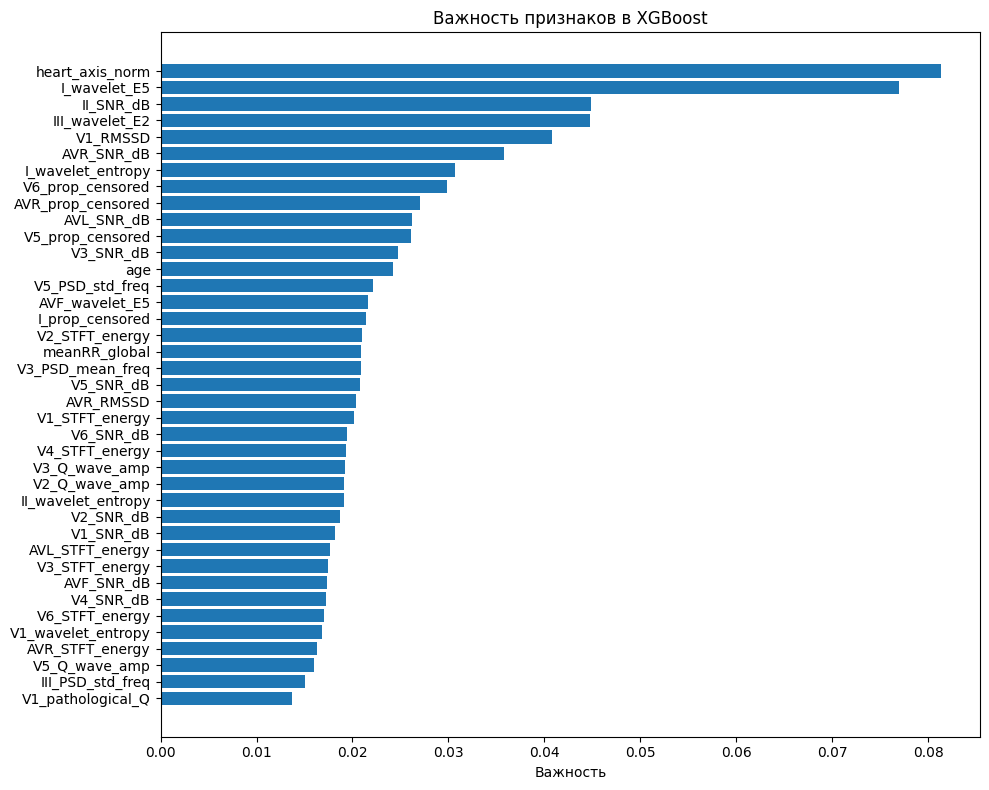

In [ ]:
best_xgb = grid_search.best_estimator_
feature_importance = best_xgb.feature_importances_

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(50))

plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(50)['feature'], importance_df.head(50)['importance'])
plt.xlabel('Важность')
plt.title('Важность признаков в XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **Итог**

Наилучшие результаты показа модель XGBoost со значением пороговой вероятности равной 0.05.

Специфика задачи прогнозирования инфаркта требует максимизации recall до 0.99-1.00. В таких условиях лучшей моделью является та, что снижает количество ложноположительных ошибок.

Модели решающего дерева и случайного леса показали большее переобучение и снижение метрики качества на валидационной и тестовой выборке относительно линейной модели логистической регрессии.

Модели градиентного бустинга показили большую устойчивость к переобучению и превзошли по качеству модель логистической регрессии.

Далее для production рекомендуется модель XGboost.